Name: Pragati Ghugal

USN: CS23134

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Gaming and Mental Health.csv to Gaming and Mental Health.csv


In [ ]:
import pandas as pd

df = pd.read_csv("Gaming and Mental Health.csv")
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [ ]:
print(df.columns)
df.info()

Index(['record_id', 'age', 'gender', 'daily_gaming_hours', 'game_genre',
       'primary_game', 'gaming_platform', 'sleep_hours', 'sleep_quality',
       'sleep_disruption_frequency', 'academic_work_performance', 'grades_gpa',
       'work_productivity_score', 'mood_state', 'mood_swing_frequency',
       'withdrawal_symptoms', 'loss_of_other_interests',
       'continued_despite_problems', 'eye_strain', 'back_neck_pain',
       'weight_change_kg', 'exercise_hours_weekly', 'social_isolation_score',
       'face_to_face_social_hours_weekly', 'monthly_game_spending_usd',
       'years_gaming', 'gaming_addiction_risk_level'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null 

In [ ]:
X = df.iloc[:, :-1]   # All columns except last
y = df.iloc[:, -1]    # Last column as target

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.885

Confusion Matrix:
 [[25  0  7  6]
 [ 0 97  2  0]
 [ 6  1 26  0]
 [ 1  0  0 29]]

Classification Report:
               precision    recall  f1-score   support

        High       0.78      0.66      0.71        38
         Low       0.99      0.98      0.98        99
    Moderate       0.74      0.79      0.76        33
      Severe       0.83      0.97      0.89        30

    accuracy                           0.89       200
   macro avg       0.84      0.85      0.84       200
weighted avg       0.89      0.89      0.88       200



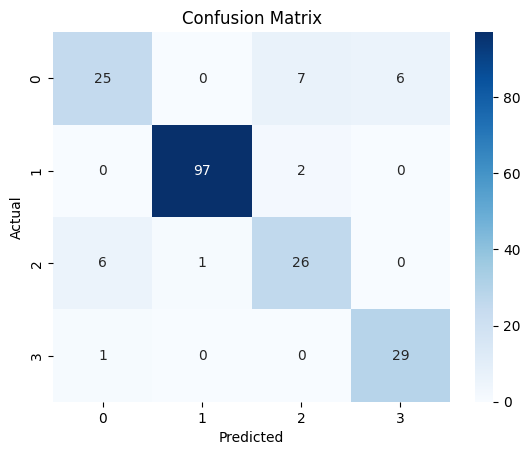

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()